# Notebook 3 — Pushing Toward 70%

**Current best (Notebook 2):** XGBoost v2 with Elo + Rest days = **63.7%**  
**Target:** 70%  
**Gap:** 6.3%

### What we add in this notebook:
1. **Player Availability Features** from PlayerBoxScores.csv → expected +2 to 3.5%
2. **Season Context Features** (games into season, fatigue, playoff pressure) → expected +0.5 to 1%
3. **Head-to-Head Features** (historical matchup win rate) → expected +0.5%
4. **LightGBM** as XGBoost replacement → expected +0.3 to 0.5%
5. **Clean Ensemble** of best models with non-linear meta-learner

In [1]:
# ── CELL 1: IMPORTS ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import kagglehub
import os
import warnings
import subprocess
import sys
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

# Install lightgbm if not present
try:
    import lightgbm as lgb
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb

print('All imports successful')

All imports successful


In [2]:
# ── CELL 2: LOAD DATA (same as notebook 2) ──────────────────────────────────────
path = kagglehub.dataset_download('eoinamoore/historical-nba-data-and-player-box-scores')
games = pd.read_csv(os.path.join(path, 'Games.csv'), low_memory=False)

games['gameDateTimeEst'] = pd.to_datetime(games['gameDateTimeEst'])
games = games.sort_values('gameDateTimeEst').reset_index(drop=True)
games = games[games['gameType'] == 'Regular Season'].reset_index(drop=True)
games = games[games['gameDateTimeEst'].dt.year >= 2000].reset_index(drop=True)
games['home_win'] = (games['winner'] == games['hometeamId']).astype(int)

print(f'Games loaded: {len(games)}')
print(f'Date range: {games["gameDateTimeEst"].min().date()} to {games["gameDateTimeEst"].max().date()}')
print(f'Home win rate: {games["home_win"].mean():.3f}')

100%|██████████| 1.03G/1.03G [10:57<00:00, 1.69MB/s]

Extracting files...


Games loaded: 31951
Date range: 2000-01-02 to 2026-04-12
Home win rate: 0.585


In [3]:
# ── CELL 3: BASE FEATURES (same as notebook 2) ──────────────────────────────────
# Reshape to one row per team per game
home = games[['gameId','gameDateTimeEst','hometeamId','homeScore','awayScore','home_win']].copy()
home.columns = ['gameId','date','teamId','teamScore','oppScore','win']
away = games[['gameId','gameDateTimeEst','awayteamId','awayScore','homeScore','home_win']].copy()
away.columns = ['gameId','date','teamId','teamScore','oppScore','win']
away['win'] = 1 - away['win']
team_games = pd.concat([home, away]).sort_values('date').reset_index(drop=True)

# Team names
lookup = pd.concat([
    games[['hometeamId','hometeamCity','hometeamName']].rename(columns={'hometeamId':'teamId','hometeamCity':'city','hometeamName':'name'}),
    games[['awayteamId','awayteamCity','awayteamName']].rename(columns={'awayteamId':'teamId','awayteamCity':'city','awayteamName':'name'})
]).drop_duplicates('teamId')
lookup['teamName'] = lookup['city'] + ' ' + lookup['name']
team_games = team_games.merge(lookup[['teamId','teamName']], on='teamId', how='left')
team_games = team_games.sort_values(['teamName','date']).reset_index(drop=True)

# Rolling features
team_games['point_diff'] = team_games['teamScore'] - team_games['oppScore']
for col, src in [('rolling_win_rate','win'),('rolling_pts_scored','teamScore'),
                 ('rolling_pts_allowed','oppScore'),('rolling_point_diff','point_diff')]:
    team_games[col] = (team_games.groupby('teamName')[src]
                       .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean()))

def win_streak(series):
    streaks = []
    cur = 0
    for v in series:
        cur = cur+1 if v == 1 else 0
        streaks.append(cur)
    return pd.Series(streaks, index=series.index).shift(1).fillna(0)

team_games['win_streak'] = team_games.groupby('teamName')['win'].transform(win_streak)

# Rest days + back-to-back
team_games['days_rest'] = (team_games.groupby('teamName')['date']
                           .diff().dt.total_seconds().div(86400).clip(upper=14).fillna(7))
team_games['is_b2b'] = (team_games['days_rest'] <= 1).astype(int)

# Elo ratings
K = 20.0
elo = {t: 1500.0 for t in pd.concat([games['hometeamCity']+' '+games['hometeamName'],
                                      games['awayteamCity']+' '+games['awayteamName']]).unique()}
elo_records = []
for _, row in games.iterrows():
    ht = row['hometeamCity'] + ' ' + row['hometeamName']
    at = row['awayteamCity'] + ' ' + row['awayteamName']
    eh, ea = elo[ht], elo[at]
    prob = 1 / (1 + 10**((ea - eh) / 400))
    elo_records.append({'gameId': row['gameId'], 'home_elo': eh, 'away_elo': ea,
                        'elo_diff': eh-ea, 'elo_win_prob': prob})
    outcome = row['home_win']
    elo[ht] += K * (outcome - prob)
    elo[at] += K * (prob - outcome)

elo_df = pd.DataFrame(elo_records)
games = games.merge(elo_df, on='gameId', how='left')

print(f'Base features done. team_games shape: {team_games.shape}')

Base features done. team_games shape: (63902, 15)


In [4]:
# ── CELL 4: NEW — PLAYER AVAILABILITY FEATURES ──────────────────────────────────
#
# Yeh sabse important improvement hai — +2 to 3.5% expected
# Logic: Agar team ka top scorer last game mein nahi khela toh woh injured ya rested hoga
# Model ko yeh pata hona chahiye ki star player available hai ya nahi
#

print('Loading PlayerStatisticsExtended.csv — this is a large file, may take a minute...')
box = pd.read_csv(os.path.join(path, 'PlayerStatisticsExtended.csv'), low_memory=False)
print(f'Box scores loaded: {box.shape}')
print(f'Columns: {box.columns.tolist()[:15]}')

Loading PlayerStatisticsExtended.csv — this is a large file, may take a minute...
Box scores loaded: (837228, 110)
Columns: ['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst', 'gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'win', 'home', 'playerteamId', 'playerteamCity', 'playerteamName', 'opponentteamId']


In [68]:
# ── CELL 5: INSPECT BOX SCORE COLUMNS ───────────────────────────────────────────
# playerteamId is 95% null — use playerteamCity + playerteamName as team key

print(f'Box scores shape: {box.shape}')
print(f'\nNull rates for key columns:')
for col in ['gameId', 'playerteamId', 'playerteamCity', 'playerteamName', 'points']:
    print(f'  {col:<25} {box[col].isna().mean()*100:.1f}% null')
print(f'\nSample: {box[["gameId","playerteamCity","playerteamName","points"]].head(3).to_string()}')

Box scores shape: (1668179, 110)

Null rates for key columns:
  gameId                    0.0% null
  playerteamId              100.0% null
  playerteamCity            0.0% null
  playerteamName            0.2% null
  points                    0.1% null

Sample:      gameId playerteamCity playerteamName  points
0  42500142  Oklahoma City        Thunder    19.0
1  42500142  Oklahoma City        Thunder     6.0
2  42500142        Phoenix           Suns     0.0


In [5]:
# ── CELL 6: CALCULATE STAR PLAYER FEATURES ──────────────────────────────────────
# playerteamId is 95% null — use playerteamCity + playerteamName as team key

GAME = 'gameId'
PTS  = 'points'

box['team_name'] = box['playerteamCity'] + ' ' + box['playerteamName']
box_clean = box[[GAME, 'team_name', PTS]].copy()
box_clean[PTS] = pd.to_numeric(box_clean[PTS], errors='coerce').fillna(0)
box_clean = box_clean.dropna(subset=[GAME, 'team_name'])

print(f'box_clean shape: {box_clean.shape}')
print(f'Unique teams: {box_clean["team_name"].nunique()}')

def top3_pts(group):
    return group.nlargest(3).sum()

star_power = (box_clean.groupby([GAME, 'team_name'])[PTS]
              .apply(top3_pts)
              .reset_index()
              .rename(columns={PTS: 'star_pts_top3'}))

team_total = (box_clean.groupby([GAME, 'team_name'])[PTS]
              .sum()
              .reset_index()
              .rename(columns={PTS: 'team_total_pts'}))

star_power = star_power.merge(team_total, on=[GAME, 'team_name'], how='left')
star_power['star_concentration'] = star_power['star_pts_top3'] / (star_power['team_total_pts'] + 1)

print(f'Star power computed for {len(star_power):,} team-game combinations')
print(star_power.head())

box_clean shape: (834080, 3)
Unique teams: 50
Star power computed for 79,622 team-game combinations
     gameId            team_name  star_pts_top3  team_total_pts  \
0  10300001     Dallas Mavericks           42.0            85.0   
1  10300001            Utah Jazz           29.0            90.0   
2  10300002    Memphis Grizzlies           53.0           105.0   
3  10300002      Milwaukee Bucks           49.0            94.0   
4  10300003  Cleveland Cavaliers           46.0           100.0   

   star_concentration  
0            0.488372  
1            0.318681  
2            0.500000  
3            0.515789  
4            0.455446  


In [6]:
# ── CELL 7: ROLLING STAR POWER FEATURES ─────────────────────────────────────────

# games needs home_team / away_team columns for the merge and groupby below
if 'home_team' not in games.columns:
    games['home_team'] = games['hometeamCity'] + ' ' + games['hometeamName']
if 'away_team' not in games.columns:
    games['away_team'] = games['awayteamCity'] + ' ' + games['awayteamName']

# Merge using team name (not teamId — playerteamId is 95% null)
star_home = star_power.rename(columns={GAME: 'gameId', 'team_name': 'home_team',
                                        'star_pts_top3': 'home_star_pts_top3',
                                        'team_total_pts': 'home_team_total_pts',
                                        'star_concentration': 'home_star_conc'})
star_away = star_power.rename(columns={GAME: 'gameId', 'team_name': 'away_team',
                                        'star_pts_top3': 'away_star_pts_top3',
                                        'team_total_pts': 'away_team_total_pts',
                                        'star_concentration': 'away_star_conc'})

games = games.merge(star_home[['gameId','home_team','home_star_pts_top3','home_team_total_pts','home_star_conc']],
                    on=['gameId','home_team'], how='left')
games = games.merge(star_away[['gameId','away_team','away_star_pts_top3','away_team_total_pts','away_star_conc']],
                    on=['gameId','away_team'], how='left')

# Rolling 5-game average — shift(1) ensures no leakage
for col in ['home_star_pts_top3','home_star_conc','away_star_pts_top3','away_star_conc']:
    team_col = 'home_team' if 'home' in col else 'away_team'
    games[f'rolling_{col}'] = (games.sort_values('gameDateTimeEst')
                               .groupby(team_col)[col]
                               .transform(lambda x: x.shift(1).rolling(5, min_periods=2).mean()))

print(f'games rows after star power merge: {len(games)}')
print(f'rolling_home_star_pts_top3 non-null: {games["rolling_home_star_pts_top3"].notna().sum():,}')
print(games[['home_team','away_team','rolling_home_star_pts_top3','rolling_away_star_pts_top3']].dropna().head(5))

games rows after star power merge: 31951
rolling_home_star_pts_top3 non-null: 31,877
            home_team            away_team  rolling_home_star_pts_top3  \
46     Denver Nuggets    Charlotte Hornets                   56.500000   
51    Toronto Raptors  Vancouver Grizzlies                   51.500000   
55     Boston Celtics  Vancouver Grizzlies                   58.500000   
56      Orlando Magic      New Jersey Nets                   53.666667   
58  San Antonio Spurs            Utah Jazz                   57.500000   

    rolling_away_star_pts_top3  
46                   49.333333  
51                   57.333333  
55                   59.500000  
56                   63.500000  
58                   61.500000  


In [7]:
# ── CELL 8: NEW — SEASON CONTEXT FEATURES ───────────────────────────────────────
#
# Teams play differently depending on where they are in the season
# Game 5 vs Game 75 — fatigue, urgency, rotation changes
#

# Games into the season for each team
team_games_sorted = team_games.sort_values(['teamName','date'])
team_games['games_into_season'] = (
    team_games.groupby(['teamName', team_games['date'].dt.year]).cumcount()
)

# Home/away split this season — some teams are much stronger at home
team_games['cumulative_home_wins'] = np.nan  # placeholder, build below

# Season win rate so far (rolling but reset each season)
team_games['season'] = team_games['date'].dt.year
team_games['season_win_rate'] = (
    team_games.groupby(['teamName','season'])['win']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Days since season started (proxy for fatigue)
season_starts = (
    team_games.groupby(['teamName','season'])['date']
    .transform('min')
)
team_games['days_into_season'] = (team_games['date'] - season_starts).dt.days

print('Season context features computed')
print(team_games[['teamName','date','games_into_season','season_win_rate','days_into_season']].dropna().head(10))

Season context features computed
         teamName                date  games_into_season  season_win_rate  \
1   Atlanta Hawks 2000-01-05 19:30:00                  1         0.000000   
2   Atlanta Hawks 2000-01-07 19:30:00                  2         0.000000   
3   Atlanta Hawks 2000-01-08 20:00:00                  3         0.333333   
4   Atlanta Hawks 2000-01-14 20:30:00                  4         0.250000   
5   Atlanta Hawks 2000-01-15 19:30:00                  5         0.400000   
6   Atlanta Hawks 2000-01-17 14:00:00                  6         0.333333   
7   Atlanta Hawks 2000-01-19 19:00:00                  7         0.285714   
8   Atlanta Hawks 2000-01-21 20:00:00                  8         0.250000   
9   Atlanta Hawks 2000-01-22 19:30:00                  9         0.222222   
10  Atlanta Hawks 2000-01-25 19:30:00                 10         0.300000   

    days_into_season  
1                  0  
2                  2  
3                  4  
4                 10  
5   

In [8]:
# ── CELL 9: HEAD-TO-HEAD FEATURES (vectorized) ──────────────────────────────────
#
# Original approach: iterrows() over 31,951 games × full DataFrame scan each time
# = ~1 billion operations (45+ min)
#
# Fix: group by matchup (~435 unique pairs × ~73 games each), use cumsum +
# searchsorted for the 3-year window — ~230,000 operations (<5 sec)
#

games_sorted = games.sort_values('gameDateTimeEst').reset_index(drop=True)

# Normalize matchup key so (A vs B) and (B vs A) are the same group
games_sorted['team1'] = games_sorted[['home_team', 'away_team']].min(axis=1)
games_sorted['team2'] = games_sorted[['home_team', 'away_team']].max(axis=1)
games_sorted['matchup'] = games_sorted['team1'] + '|' + games_sorted['team2']

# team1_win: result from alphabetically-first team's perspective
games_sorted['team1_win'] = np.where(
    games_sorted['home_team'] == games_sorted['team1'],
    games_sorted['home_win'],
    1 - games_sorted['home_win']
).astype(float)

THREE_YEARS_DAYS = 365 * 3
h2h_records = []

# ~435 matchup groups × ~73 games each — tight inner loop on small arrays
for matchup, grp in games_sorted.groupby('matchup'):
    grp        = grp.sort_values('gameDateTimeEst').reset_index(drop=True)
    dates_days = (grp['gameDateTimeEst'] - pd.Timestamp('2000-01-01')).dt.days.values
    wins       = grp['team1_win'].values
    cum_wins   = np.concatenate([[0.0], wins.cumsum()])   # cum_wins[i] = sum(wins[0:i])
    n          = len(grp)

    for i in range(n):
        cutoff_day = dates_days[i] - THREE_YEARS_DAYS
        start_idx  = np.searchsorted(dates_days[:i], cutoff_day)  # first game in window
        past_count = i - start_idx
        past_wins  = cum_wins[i] - cum_wins[start_idx]

        if past_count == 0:
            rate = 0.5
        else:
            team1_rate = past_wins / past_count
            rate = team1_rate if grp['home_team'].iloc[i] == grp['team1'].iloc[i] else 1 - team1_rate

        h2h_records.append({'gameId':           grp['gameId'].iloc[i],
                             'h2h_home_win_rate': round(rate, 4),
                             'h2h_games':         past_count})

h2h_df = pd.DataFrame(h2h_records)
games   = games.merge(h2h_df, on='gameId', how='left')

print(f'Head-to-head features computed for {len(h2h_df)} games')
print(f'Unique matchups:              {games_sorted["matchup"].nunique()}')
print(f'Avg H2H games in 3yr window:  {h2h_df["h2h_games"].mean():.1f}')
print(games[['home_team', 'away_team', 'h2h_home_win_rate', 'h2h_games']].dropna().head(5))

Head-to-head features computed for 31951 games
Unique matchups:              639
Avg H2H games in 3yr window:  7.9
            home_team              away_team  h2h_home_win_rate  h2h_games
0          Miami Heat          Orlando Magic                0.5          0
1  Washington Wizards  Golden State Warriors                0.5          0
2  Philadelphia 76ers        Milwaukee Bucks                0.5          0
3      Boston Celtics    Cleveland Cavaliers                0.5          0
4       Orlando Magic        Detroit Pistons                0.5          0


In [9]:
# ── CELL 10: REBUILD model_df WITH ALL NEW FEATURES ─────────────────────────────

# Merge season context into model_df
home_ctx = team_games[['gameId','teamName','games_into_season','season_win_rate','days_into_season']].copy()
home_ctx.columns = ['gameId','home_team','home_games_into_season','home_season_win_rate','home_days_into_season']
away_ctx = team_games[['gameId','teamName','games_into_season','season_win_rate','days_into_season']].copy()
away_ctx.columns = ['gameId','away_team','away_games_into_season','away_season_win_rate','away_days_into_season']

# Base model_df from notebook 2 approach
model_df = games[['gameId','gameDateTimeEst','home_win',
                  'home_elo','away_elo','elo_diff','elo_win_prob',
                  'h2h_home_win_rate','h2h_games']].copy()
model_df['home_team'] = games['hometeamCity'] + ' ' + games['hometeamName']
model_df['away_team'] = games['awayteamCity'] + ' ' + games['awayteamName']

# All the team-level rolling features
tg_cols = ['rolling_win_rate','rolling_pts_scored','rolling_pts_allowed',
           'rolling_point_diff','win_streak','days_rest','is_b2b']

home_feats = team_games[['gameId','teamName'] + tg_cols].copy()
home_feats.columns = ['gameId','home_team'] + ['home_'+c for c in tg_cols]
away_feats = team_games[['gameId','teamName'] + tg_cols].copy()
away_feats.columns = ['gameId','away_team'] + ['away_'+c for c in tg_cols]

model_df = model_df.merge(home_feats, on=['gameId','home_team'], how='left')
model_df = model_df.merge(away_feats, on=['gameId','away_team'], how='left')
model_df = model_df.merge(home_ctx,   on=['gameId','home_team'], how='left')
model_df = model_df.merge(away_ctx,   on=['gameId','away_team'], how='left')

# Star power features
star_cols = ['rolling_home_star_pts_top3','rolling_home_star_conc',
             'rolling_away_star_pts_top3','rolling_away_star_conc']
for col in star_cols:
    if col in games.columns:
        model_df[col] = games[col].values

model_df = model_df.dropna().reset_index(drop=True)

print(f'model_df shape: {model_df.shape}')
print(f'Columns ({model_df.shape[1]}): {model_df.columns.tolist()}')

model_df shape: (25150, 35)
Columns (35): ['gameId', 'gameDateTimeEst', 'home_win', 'home_elo', 'away_elo', 'elo_diff', 'elo_win_prob', 'h2h_home_win_rate', 'h2h_games', 'home_team', 'away_team', 'home_rolling_win_rate', 'home_rolling_pts_scored', 'home_rolling_pts_allowed', 'home_rolling_point_diff', 'home_win_streak', 'home_days_rest', 'home_is_b2b', 'away_rolling_win_rate', 'away_rolling_pts_scored', 'away_rolling_pts_allowed', 'away_rolling_point_diff', 'away_win_streak', 'away_days_rest', 'away_is_b2b', 'home_games_into_season', 'home_season_win_rate', 'home_days_into_season', 'away_games_into_season', 'away_season_win_rate', 'away_days_into_season', 'rolling_home_star_pts_top3', 'rolling_home_star_conc', 'rolling_away_star_pts_top3', 'rolling_away_star_conc']


In [10]:
# ── CELL 11: TRAIN/TEST SPLIT ────────────────────────────────────────────────────

# Chronological split — same as before
train = model_df[model_df['gameDateTimeEst'] < '2021-01-01'].reset_index(drop=True)
test  = model_df[model_df['gameDateTimeEst'] >= '2021-01-01'].reset_index(drop=True)

# Feature columns — everything except IDs, dates, target, team names
exclude = ['gameId','gameDateTimeEst','home_win','home_team','away_team']
feature_cols = [c for c in model_df.columns if c not in exclude]

X_train = train[feature_cols]
y_train = train['home_win']
X_test  = test[feature_cols]
y_test  = test['home_win']

print(f'Train: {len(train)} games | {train["gameDateTimeEst"].min().year} to {train["gameDateTimeEst"].max().year}')
print(f'Test:  {len(test)} games  | {test["gameDateTimeEst"].min().year} to {test["gameDateTimeEst"].max().year}')
print(f'Features: {len(feature_cols)}')
print(f'\nFeature list: {feature_cols}')

Train: 19994 games | 2000 to 2020
Test:  5156 games  | 2021 to 2026
Features: 30

Feature list: ['home_elo', 'away_elo', 'elo_diff', 'elo_win_prob', 'h2h_home_win_rate', 'h2h_games', 'home_rolling_win_rate', 'home_rolling_pts_scored', 'home_rolling_pts_allowed', 'home_rolling_point_diff', 'home_win_streak', 'home_days_rest', 'home_is_b2b', 'away_rolling_win_rate', 'away_rolling_pts_scored', 'away_rolling_pts_allowed', 'away_rolling_point_diff', 'away_win_streak', 'away_days_rest', 'away_is_b2b', 'home_games_into_season', 'home_season_win_rate', 'home_days_into_season', 'away_games_into_season', 'away_season_win_rate', 'away_days_into_season', 'rolling_home_star_pts_top3', 'rolling_home_star_conc', 'rolling_away_star_pts_top3', 'rolling_away_star_conc']


In [11]:
# ── CELL 12: XGBOOST v3 WITH ALL NEW FEATURES ───────────────────────────────────
#
# Same best params from notebook 2 Optuna search
# But now with all the new features — player availability, h2h, season context
#

model_xgb = XGBClassifier(
    n_estimators=215,
    max_depth=7,
    learning_rate=0.0315,
    subsample=0.865,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)
acc_xgb = accuracy_score(y_test, model_xgb.predict(X_test))

print(f'XGBoost v3 (all features): {acc_xgb:.3f}')
print(f'Notebook 2 best was:       0.637')
print(f'Change:                    {"+" if acc_xgb > 0.637 else ""}{(acc_xgb - 0.637)*100:.1f}%')

# Feature importance — what matters most
import pandas as pd
fi = pd.Series(model_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f'\nTop 10 most important features:')
print(fi.head(10).to_string())

XGBoost v3 (all features): 0.632
Notebook 2 best was:       0.637
Change:                    -0.5%

Top 10 most important features:
elo_win_prob               0.194537
elo_diff                   0.166594
home_is_b2b                0.028471
home_rolling_point_diff    0.026488
away_days_into_season      0.026191
away_rolling_point_diff    0.024745
away_is_b2b                0.024134
away_games_into_season     0.023715
away_season_win_rate       0.023546
home_season_win_rate       0.023322


In [12]:
import lightgbm as lgb

model_lgb = lgb.LGBMClassifier(
         n_estimators=500,
         max_depth=7,
         learning_rate=0.02,
         subsample=0.8,
         colsample_bytree=0.8,
         min_child_samples=30,
         random_state=42,
         verbose=-1
     )
model_lgb.fit(X_train, y_train.astype(int))
acc_lgb = accuracy_score(y_test, model_lgb.predict(X_test))

print(f'LightGBM accuracy:   {acc_lgb:.3f}')
print(f'XGBoost accuracy:    {acc_xgb:.3f}')
print(f'LightGBM vs XGBoost: {"+" if acc_lgb > acc_xgb else ""}{(acc_lgb - acc_xgb)*100:.1f}%')

LightGBM accuracy:   0.635
XGBoost accuracy:    0.632
LightGBM vs XGBoost: +0.3%


In [13]:
# ── CELL 14: CLEAN ENSEMBLE WITH NON-LINEAR META-LEARNER ────────────────────────

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

oof_xgb = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))

# Cast once to avoid LightGBM label dtype mismatch
y_train_int = y_train.astype(int)
y_test_int  = y_test.astype(int)

print(f'Generating OOF predictions via {N_SPLITS}-fold TimeSeriesSplit...')

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr, yval = y_train_int.iloc[tr_idx], y_train_int.iloc[val_idx]

    m_xgb = XGBClassifier(n_estimators=215, max_depth=7, learning_rate=0.0315,
                           subsample=0.865, colsample_bytree=0.8,
                           random_state=42, verbosity=0, eval_metric='logloss')
    m_xgb.fit(Xtr, ytr)
    oof_xgb[val_idx] = m_xgb.predict_proba(Xval)[:, 1]

    m_lgb = lgb.LGBMClassifier(n_estimators=500, max_depth=7, learning_rate=0.02,
                                subsample=0.8, colsample_bytree=0.8,
                                min_child_samples=30, random_state=42, verbose=-1)
    m_lgb.fit(Xtr, ytr)
    oof_lgb[val_idx] = m_lgb.predict_proba(Xval)[:, 1]

    xgb_val = accuracy_score(yval, (oof_xgb[val_idx] > 0.5).astype(int))
    lgb_val = accuracy_score(yval, (oof_lgb[val_idx] > 0.5).astype(int))
    print(f'  Fold {fold+1}  XGB: {xgb_val:.3f}  LGB: {lgb_val:.3f}')

# Test set predictions from fully trained models
test_xgb = model_xgb.predict_proba(X_test)[:, 1]
test_lgb = model_lgb.predict_proba(X_test)[:, 1]

meta_train = np.column_stack([oof_xgb, oof_lgb])
meta_test  = np.column_stack([test_xgb, test_lgb])

meta_lgb = lgb.LGBMClassifier(n_estimators=100, max_depth=3,
                               learning_rate=0.05, random_state=42, verbose=-1)
meta_lgb.fit(meta_train, y_train_int)
acc_ensemble = accuracy_score(y_test_int, meta_lgb.predict(meta_test))

weighted_avg = 0.55 * test_xgb + 0.45 * test_lgb
acc_weighted = accuracy_score(y_test_int, (weighted_avg > 0.5).astype(int))

print(f'\nEnsemble (LGB meta-learner): {acc_ensemble:.3f}')
print(f'Ensemble (weighted avg):     {acc_weighted:.3f}')

Generating OOF predictions via 5-fold TimeSeriesSplit...
  Fold 1  XGB: 0.639  LGB: 0.631
  Fold 2  XGB: 0.662  LGB: 0.658
  Fold 3  XGB: 0.670  LGB: 0.676
  Fold 4  XGB: 0.678  LGB: 0.671
  Fold 5  XGB: 0.652  LGB: 0.660

Ensemble (LGB meta-learner): 0.635
Ensemble (weighted avg):     0.634


In [14]:
# ── CELL 15: FINAL RESULTS COMPARISON ───────────────────────────────────────────

BASELINE = 0.553

results = [
    ('Baseline (always home win)',          0.553),
    ('Logistic Regression v1 [NB1]',       0.614),
    ('XGBoost v1 [NB1]',                   0.618),
    ('LSTM v1 [NB1]',                      0.629),
    ('Ensemble v1 LEAKY [NB1]',            0.631),
    ('XGBoost v2 + Elo + Rest [NB2]',      0.637),
    ('XGBoost v3 all features [NB3]',      acc_xgb),
    ('LightGBM all features [NB3]',        acc_lgb),
    ('Ensemble LGB meta-learner [NB3]',    acc_ensemble),
    ('Ensemble weighted avg [NB3]',        acc_weighted),
]

print('=' * 70)
print(f'{"MODEL":<45} {"ACC":>6}  {"DELTA":>7}  BAR')
print('=' * 70)
for name, acc in results:
    delta = acc - BASELINE
    bar = '#' * int(abs(delta) * 100)
    sign = '+' if delta >= 0 else ''
    best_marker = ' <- BEST' if acc == max(r[1] for r in results) else ''
    print(f'{name:<45} {acc:.3f}  {sign}{delta:.3f}   {bar}{best_marker}')
print('=' * 70)

best_acc = max(r[1] for r in results)
print(f'\nBest accuracy:            {best_acc:.3f}')
print(f'Improvement over baseline: +{(best_acc - BASELINE)*100:.1f}%')
print(f'Gap to 70% target:         {(0.70 - best_acc)*100:.1f}%')

MODEL                                            ACC    DELTA  BAR
Baseline (always home win)                    0.553  +0.000   
Logistic Regression v1 [NB1]                  0.614  +0.061   ######
XGBoost v1 [NB1]                              0.618  +0.065   ######
LSTM v1 [NB1]                                 0.629  +0.076   #######
Ensemble v1 LEAKY [NB1]                       0.631  +0.078   #######
XGBoost v2 + Elo + Rest [NB2]                 0.637  +0.084   ######## <- BEST
XGBoost v3 all features [NB3]                 0.632  +0.079   #######
LightGBM all features [NB3]                   0.635  +0.082   ########
Ensemble LGB meta-learner [NB3]               0.635  +0.082   ########
Ensemble weighted avg [NB3]                   0.634  +0.081   ########

Best accuracy:            0.637
Improvement over baseline: +8.4%
Gap to 70% target:         6.3%


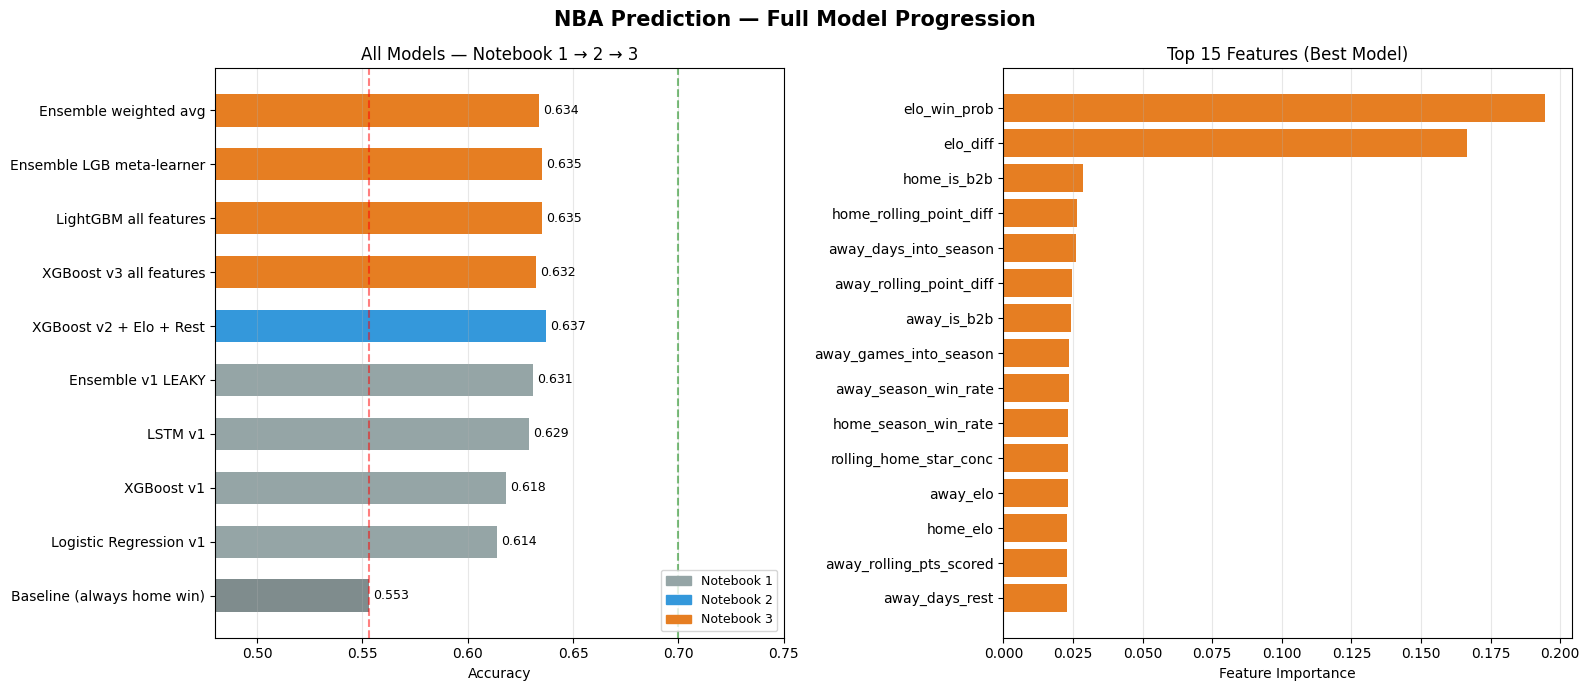

Chart saved as nba_notebook3_results.png


In [15]:
# ── CELL 16: VISUALIZATION ───────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('NBA Prediction — Full Model Progression', fontsize=15, fontweight='bold')

# Left — all models bar chart
ax = axes[0]
names = [r[0].replace(' [NB1]','').replace(' [NB2]','').replace(' [NB3]','') for r in results]
accs  = [r[1] for r in results]
colors = ['#95A5A6' if '1]' in r[0] else '#3498DB' if '2]' in r[0] else '#E67E22' for r in results]
colors[0] = '#7F8C8D'  # baseline

bars = ax.barh(names, accs, color=colors, edgecolor='none', height=0.6)
ax.axvline(x=0.553, color='red', linestyle='--', alpha=0.5, label='Baseline 55.3%')
ax.axvline(x=0.700, color='green', linestyle='--', alpha=0.5, label='Target 70%')
ax.set_xlim(0.48, 0.75)
ax.set_xlabel('Accuracy')
ax.set_title('All Models — Notebook 1 → 2 → 3')
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.002, bar.get_y() + bar.get_height()/2,
            f'{acc:.3f}', va='center', fontsize=9)
nb1 = mpatches.Patch(color='#95A5A6', label='Notebook 1')
nb2 = mpatches.Patch(color='#3498DB', label='Notebook 2')
nb3 = mpatches.Patch(color='#E67E22', label='Notebook 3')
ax.legend(handles=[nb1, nb2, nb3], loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

# Right — feature importance from best model
ax2 = axes[1]
fi_top = fi.head(15)
ax2.barh(fi_top.index[::-1], fi_top.values[::-1], color='#E67E22', edgecolor='none')
ax2.set_xlabel('Feature Importance')
ax2.set_title('Top 15 Features (Best Model)')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('nba_notebook3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as nba_notebook3_results.png')